# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename = "/home/friday/data3402/DATA3402.Spring.2026.FS/Labs/Lab.7.submission/SUSY.csv" 

VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"] 

df = pd.read_csv(filename, dtype='float64', names=VarNames) 

In [3]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


In [14]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

Exercise 1 status:

I have installed scikit-learn in my powershell

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


In [ ]:
# part a --> classification algorithms

#linear models
#Linear and quadratic discriminant analysis
#Kernel ridge regression
#Support Vector Machines
#Stochastic Gradient Descent
#Nearest Neighbors
#Gaussian Processes
#Cross Decomposition
#Naive Bayes
#Decision Trees
#Ensembles
#Multiclass and Multioutput Algorithms
#Feature Selection
#more

In [ ]:
# part b --> look through linear models

In [4]:
# Next step read through documentation and take notes on LDA (linear discriminant analysis)

# easily computed, are inherently multiclass, have proven to work well in practice, and have no hyperparameters to tune

#perform supervised dimensionality reduction which only makes sense in a multiclass setting

#LDA, in contrast to PCA, is a supervised method, using known class labels

#Gaussians for each class are assumed to share the same covariance matrix

#Below is log posterior reduction:

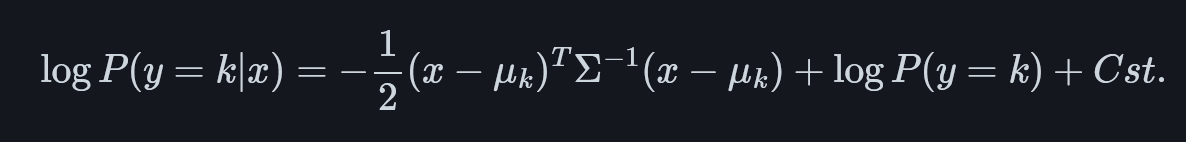

In [5]:
# Mahalanobis distance --> how close a sample is with the mean while considering the variance of each feature

#LDA --> assigns samples to their classes which minimize this distance
#linear decision surface

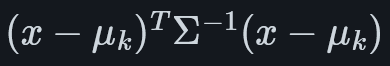

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA #importing LDA from the module sklearn
Fisher=DA.LinearDiscriminantAnalysis() #creating an instance of the LDA function

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [91]:
N_Train=4000000 #setting aside 4 million events for training

Train_Sample=df[:N_Train] #all instances up until 4 million are training events
Test_Sample=df[N_Train:] #everything afterwards are test sample

X_Train=Train_Sample[VarNames[1:]] #all but signal column corresponds to features we want to train with
y_Train=Train_Sample["signal"] #signal is the label

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1] #selecting the test samples that correspond to signal 
Test_bkg=Test_Sample[Test_Sample.signal==0] #selecting the test samples that correspond to background


In [10]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


In [13]:
Train_Sample

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999995,1.0,1.002406,0.385042,1.331986,1.525072,-1.197863,1.286476,1.514978,1.128357,0.666884,1.751115,1.489893,0.326757,0.194619,0.686811,1.123048,0.550671,0.659141,0.007232
3999996,0.0,0.425602,-1.589667,0.657618,0.575109,-1.646749,-1.352795,0.426123,0.308892,0.238181,0.321252,0.401980,0.454282,1.002855,0.457667,0.410559,0.341658,1.163467,0.210449
3999997,0.0,0.926546,0.269231,0.956893,1.223767,1.209497,-0.990745,0.764778,-0.207391,1.132645,-0.437361,1.009248,0.988819,0.869429,1.175635,1.043642,0.988448,1.485969,0.114856
3999998,0.0,0.447816,1.157764,-0.562344,0.518973,1.086016,1.511437,0.149221,-1.672102,0.108188,0.358421,0.395729,0.253846,0.569231,0.000000,0.378764,0.089636,0.567347,0.172778


In [63]:
test_sig=Test_Sample[Test_Sample.signal==1]
test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [64]:
Fisher.fit(X_Train,y_Train) #fitting the training data to the LDA function instance

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


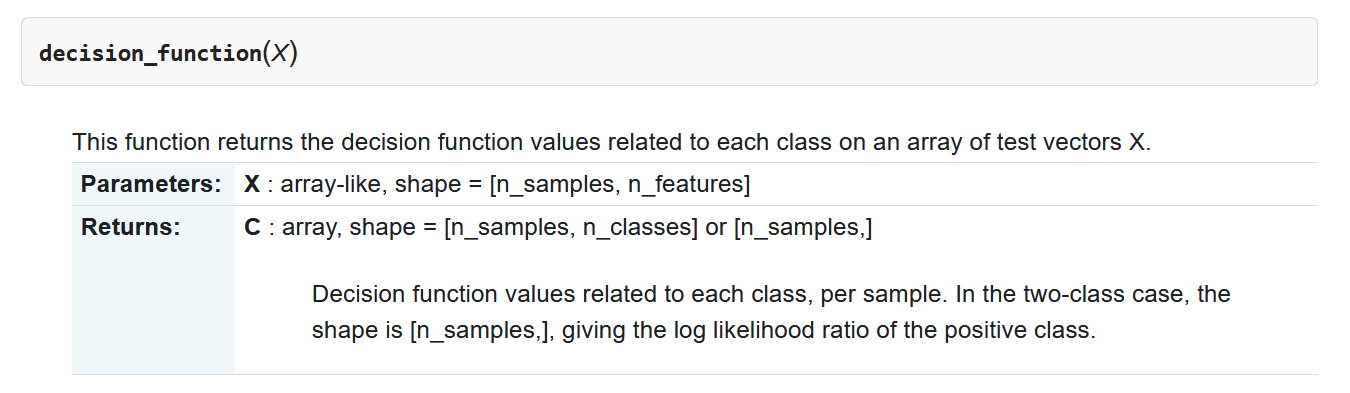

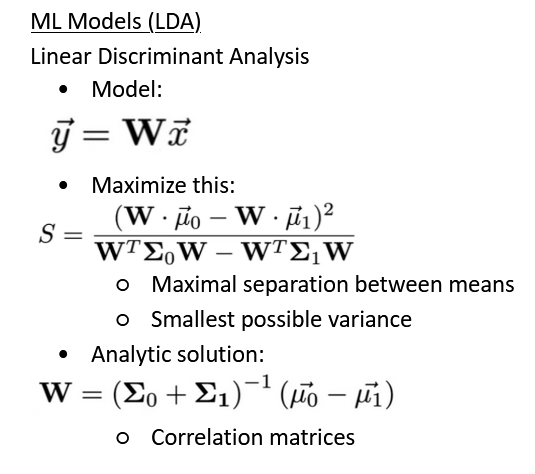

We can plot the output, comparing signal and background:

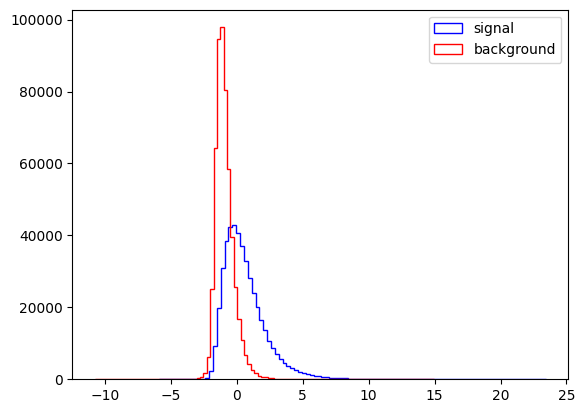

In [65]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True) #histogramming instances of test signals
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True) #histogramming instances of test backgrounds
plt.legend(loc='upper right') #location of the legend in the upper right corner
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [ ]:
#training samples

train_sig=Train_Sample[Train_Sample.signal==1]
train_bkg=Train_Sample[Train_Sample.signal==0]

In [19]:
scenarios = { "1": (10,100), 
              "2": (100,1000),
              "2.1": (200,2000),
              "2.2": (300,3000),
              "2.3": (400,4000),
              "2.4": (500,5000),
              "3": (1000,10000),
              "4": (10000,100000)
            }

In [20]:
def compute_rate(d,bins=100):
    hist,bins_=np.histogram(d,bins=bins,density=True)
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1]-bins_[0])
    return R,bins_

In [31]:
def compare_significance(train_sig, train_bkg,
                         obs_name,
                         scenarios,bins=100,log=False):
        
    TPR,bins_sig = compute_rate(train_sig[obs_name],bins=bins)
    FPR,bins_sig = compute_rate(train_bkg[obs_name],bins=bins_sig)
    
    max_sigs=dict()
    table=list()
    
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():

        n_sig_expected_prime = n_sig_expected * TPR
        n_bkg_expected_prime = n_bkg_expected * FPR

        sig = n_sig_expected_prime/ np.sqrt(n_sig_expected_prime + n_bkg_expected_prime )
        plt.step(bins_sig[:-1],sig,label=name+" "+str((n_sig_expected, n_bkg_expected)))
    
        max_i=np.argmax(sig)
        max_sigs[name]=(max_i,n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i])
        table.append((name,n_sig_expected, n_bkg_expected, 
                      TPR[max_i],FPR[max_i],
                      n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i],max_i)
        )
    if log:
        plt.yscale("log")
    plt.legend()
    plt.show()

    plt.plot(FPR,TPR) #ROC curve for training set
    plt.show()
    
    display(HTML(tabulate.tabulate(table, tablefmt='html',
                                   headers=["Name",'N sig','N bkg',"TPR","FPR","N sig'","N bkg'",'sig','x_c',"bin i"])))
    return max_sigs


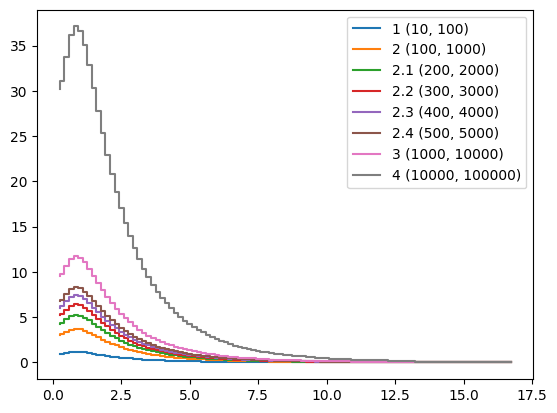

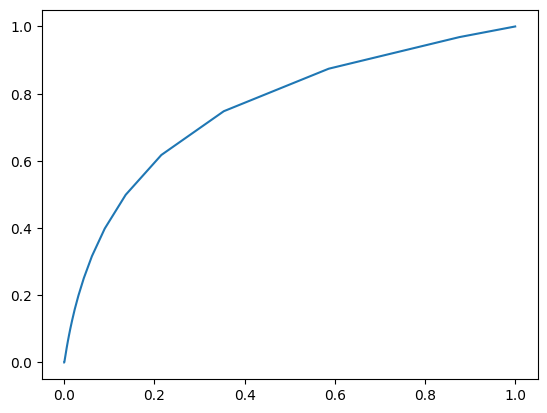

Name,N sig,N bkg,TPR,FPR,N sig',N bkg',sig,x_c,bin i
1,10,100,0.617529,0.215271,6.17529,21.5271,1.17327,0.920689,4
2,100,1000,0.617529,0.215271,61.7529,215.271,3.71021,0.920689,4
2.1,200,2000,0.617529,0.215271,123.506,430.542,5.24704,0.920689,4
2.2,300,3000,0.617529,0.215271,185.259,645.813,6.42628,0.920689,4
2.3,400,4000,0.617529,0.215271,247.012,861.084,7.42043,0.920689,4
2.4,500,5000,0.617529,0.215271,308.765,1076.35,8.29629,0.920689,4
3,1000,10000,0.617529,0.215271,617.529,2152.71,11.7327,0.920689,4
4,10000,100000,0.617529,0.215271,6175.29,21527.1,37.1021,0.920689,4


In [32]:
_=compare_significance(train_sig, train_bkg, "l_1_pT", scenarios)

In [25]:
#test samples

test_sig=Test_Sample[Test_Sample.signal==1]
test_bkg=Test_Sample[Test_Sample.signal==0]

In [33]:
def compare_significance(test_sig, test_bkg,
                         obs_name,
                         scenarios,bins=100,log=False):
        
    TPR,bins_sig = compute_rate(test_sig[obs_name],bins=bins)
    FPR,bins_sig = compute_rate(test_bkg[obs_name],bins=bins_sig)
    
    max_sigs=dict()
    table=list()
    
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():

        n_sig_expected_prime = n_sig_expected * TPR
        n_bkg_expected_prime = n_bkg_expected * FPR

        sig = n_sig_expected_prime/ np.sqrt(n_sig_expected_prime + n_bkg_expected_prime )
        plt.step(bins_sig[:-1],sig,label=name+" "+str((n_sig_expected, n_bkg_expected)))
    
        max_i=np.argmax(sig)
        max_sigs[name]=(max_i,n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i])
        table.append((name,n_sig_expected, n_bkg_expected, 
                      TPR[max_i],FPR[max_i],
                      n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i],max_i)
        )
    if log:
        plt.yscale("log")
    plt.legend()
    plt.show()

    plt.plot(FPR,TPR) #ROC curve for test set
    plt.show()
    
    display(HTML(tabulate.tabulate(table, tablefmt='html',
                                   headers=["Name",'N sig','N bkg',"TPR","FPR","N sig'","N bkg'",'sig','x_c',"bin i"])))
    return max_sigs

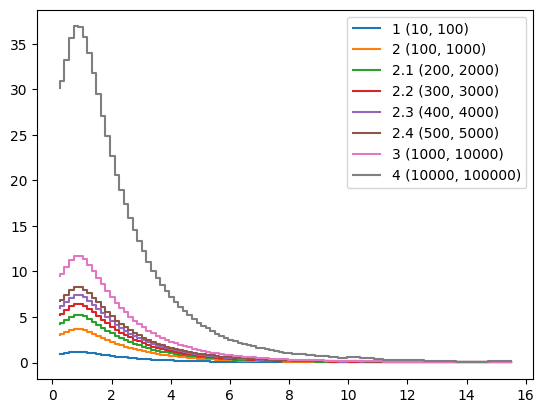

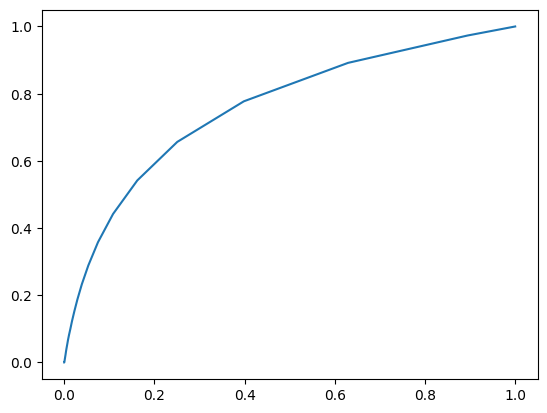

Name,N sig,N bkg,TPR,FPR,N sig',N bkg',sig,x_c,bin i
1,10,100,0.65652,0.250654,6.5652,25.0654,1.16733,0.870963,4
2,100,1000,0.65652,0.250654,65.652,250.654,3.69143,0.870963,4
2.1,200,2000,0.65652,0.250654,131.304,501.308,5.22046,0.870963,4
2.2,300,3000,0.65652,0.250654,196.956,751.962,6.39374,0.870963,4
2.3,400,4000,0.65652,0.250654,262.608,1002.62,7.38285,0.870963,4
2.4,500,5000,0.65652,0.250654,328.26,1253.27,8.25428,0.870963,4
3,1000,10000,0.65652,0.250654,656.52,2506.54,11.6733,0.870963,4
4,10000,100000,0.65652,0.250654,6565.2,25065.4,36.9143,0.870963,4


In [34]:
_=compare_significance(test_sig, test_bkg, "l_1_pT", scenarios)

In [39]:
def compare_ROC(train_sig, train_bkg, test_sig, test_bkg,
                         obs_name,
                         scenarios,bins=100,log=False):
        
    train_TPR,bins_sig = compute_rate(train_sig[obs_name],bins=bins)
    train_FPR,bins_sig = compute_rate(train_bkg[obs_name],bins=bins_sig)

    test_TPR,bins_sig = compute_rate(test_sig[obs_name],bins=bins)
    test_FPR,bins_sig = compute_rate(test_bkg[obs_name],bins=bins_sig)

    plt.plot(train_FPR,train_TPR, label="train") #ROC curve for train set
    plt.plot(test_FPR,test_TPR, label="test")

    plt.legend()
    plt.show()

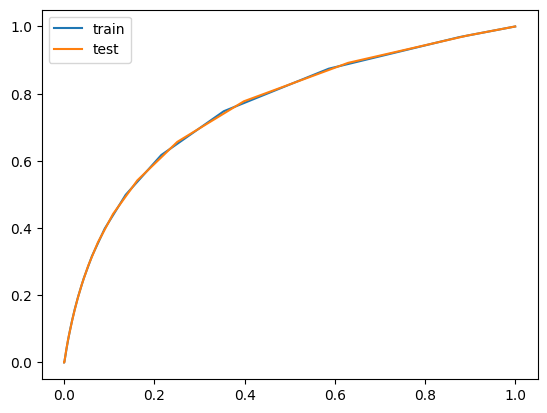

In [40]:
compare_ROC(train_sig, train_bkg, test_sig, test_bkg, "l_1_pT", scenarios)

In [43]:
my_obs= ['MET',
 'MET_phi',
 'MET_rel',
 'axial_MET',
 'M_R',
 'M_TR_2',
 'R',
 'MT2',
 'S_R',
 'M_Delta_R',
 'dPhi_r_b',
 'cos_theta_r1']

MET


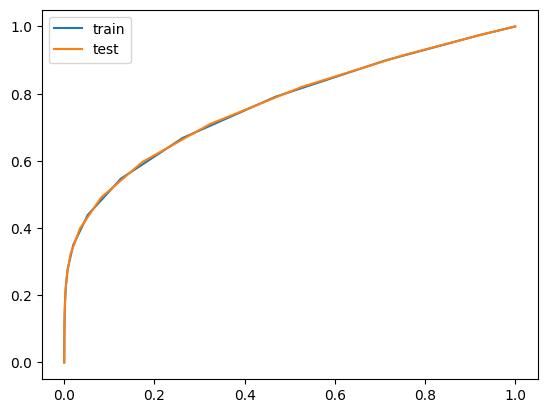

MET_phi


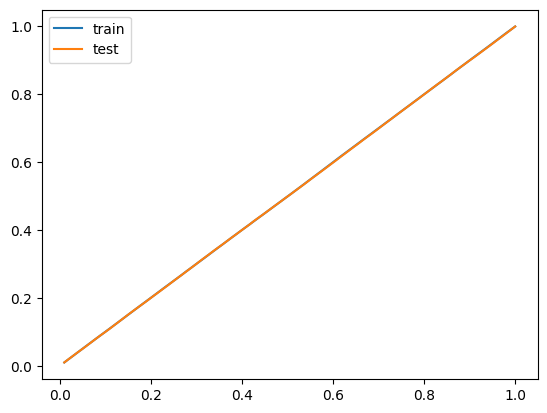

MET_rel


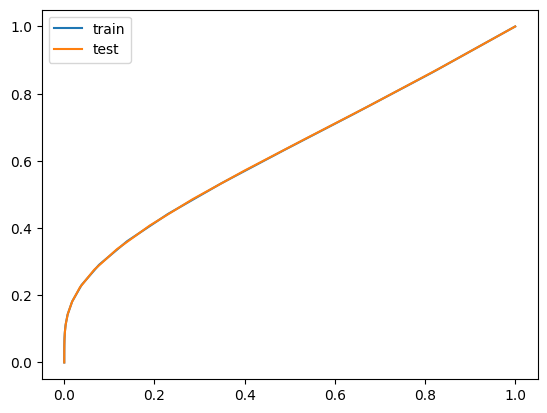

axial_MET


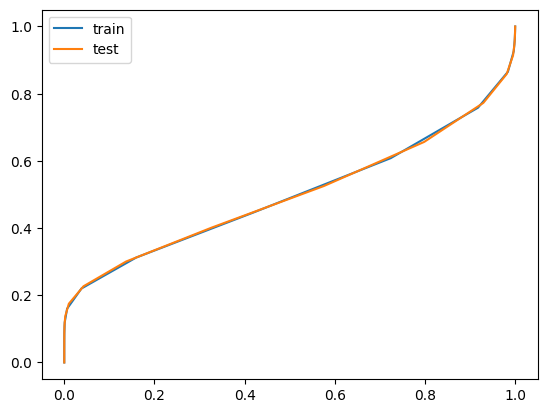

M_R


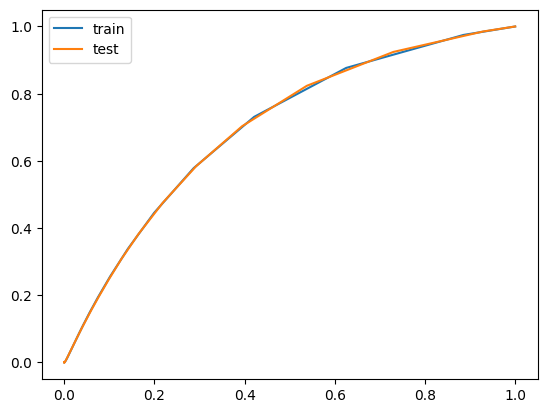

M_TR_2


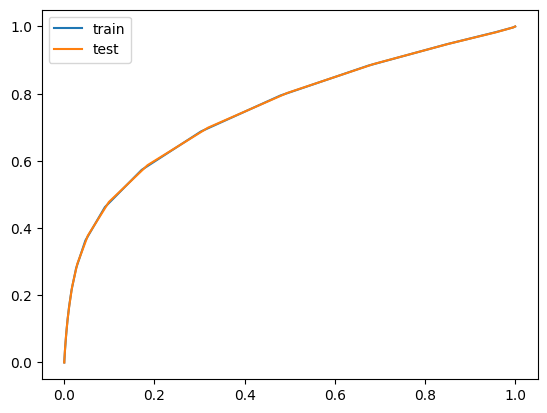

R


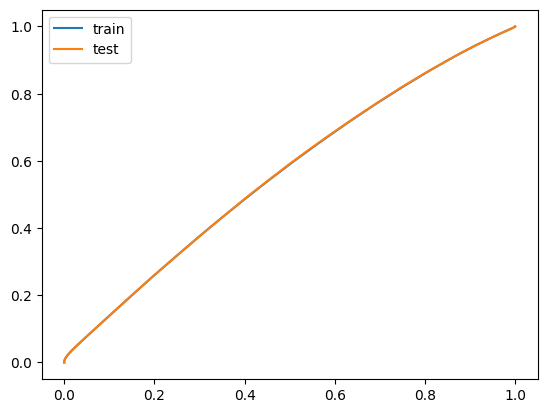

MT2


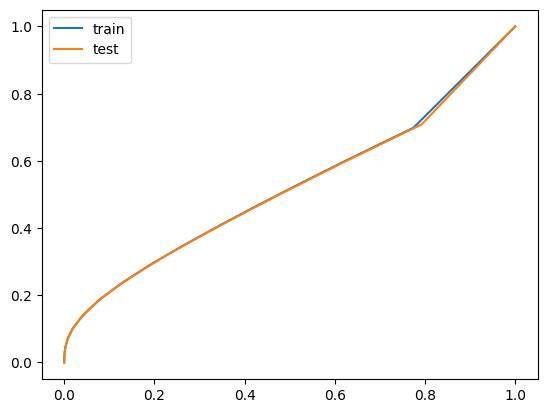

S_R


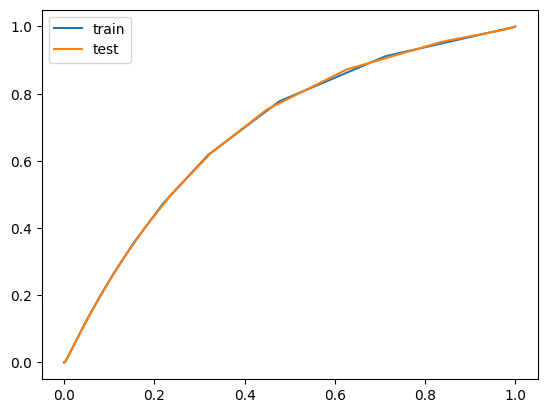

M_Delta_R


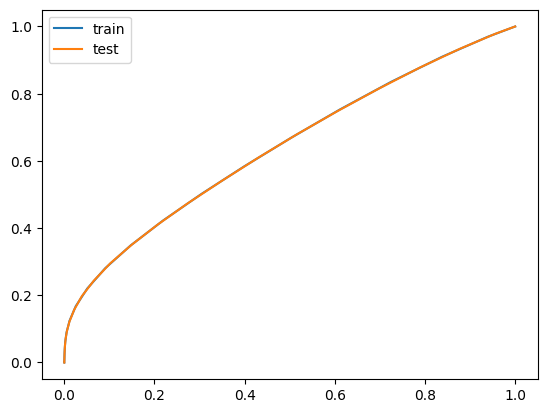

dPhi_r_b


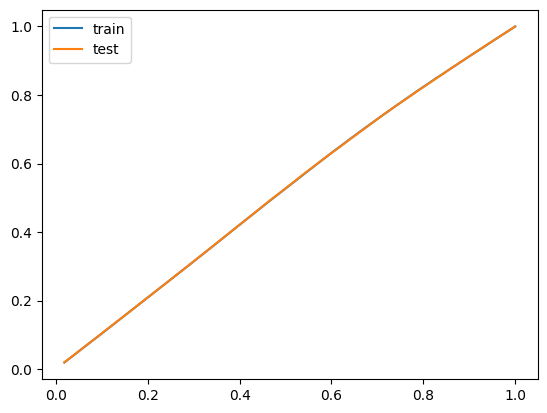

cos_theta_r1


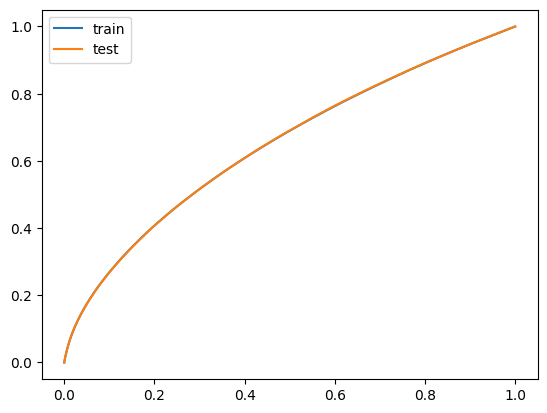

In [44]:
for obs in my_obs:
    print(obs)
    _=compare_ROC(train_sig, train_bkg, test_sig, test_bkg, obs,scenarios)
    

In [ ]:
# Although the last two plots look quite similar, they are slightly different. This is because we are setting a portion of the data from the
# original dataframe into training set (larger than test) and test sets (smaller than training). One might expect that the larger dataset would be
# more generalized to the population (and therefore less biased than the smaller sample) but with this example, the differences are not too large

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [57]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [58]:
X1_Train=Train_Sample[RawNames[1:]] #all but signal column corresponds to features we want to train with (fitting RawNames)
y1_Train=Train_Sample["signal"] #signal is the label

X2_Train=Train_Sample[FeatureNames[1:]] #all but signal column corresponds to features we want to train with (fitting FeatureNames)
y2_Train=Train_Sample["signal"] #signal is the label

In [60]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

raw_fisher = LinearDiscriminantAnalysis() #create a new LDA instance that will support raw inputs
feature_fisher = LinearDiscriminantAnalysis() #create a new LDA instance that will support feature inputs

raw_fisher.fit(X1_Train, y1_Train)
feature_fisher.fit(X2_Train, y2_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


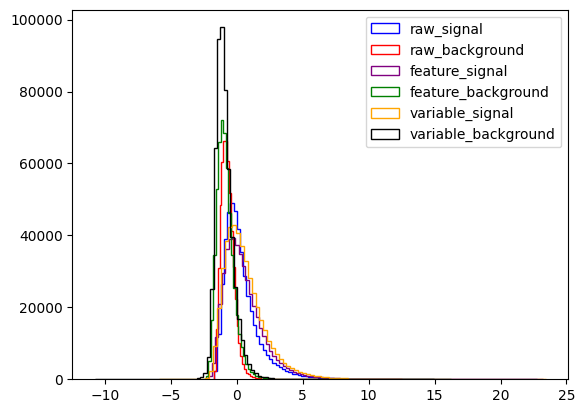

In [67]:
plt.figure()
plt.hist(raw_fisher.decision_function(Test_sig[RawNames[1:]]),bins=100,histtype="step", color="blue", label="raw_signal",stacked=True) #histogramming instances of test signals
plt.hist(raw_fisher.decision_function(Test_bkg[RawNames[1:]]),bins=100,histtype="step", color="red", label="raw_background",stacked=True) #histogramming instances of test backgrounds
plt.hist(feature_fisher.decision_function(Test_sig[FeatureNames[1:]]),bins=100,histtype="step", color="purple", label="feature_signal",stacked=True) #histogramming instances of test signals
plt.hist(feature_fisher.decision_function(Test_bkg[FeatureNames[1:]]),bins=100,histtype="step", color="green", label="feature_background",stacked=True) #histogramming instances of test backgrounds
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="orange", label="variable_signal",stacked=True) #histogramming instances of test signals
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="black", label="variable_background",stacked=True) #histogramming instances of test backgrounds
plt.legend(loc='upper right') #location of the legend in the upper right corner
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [ ]:
#part a

#classifier 1 --> RidgeClassifier
#classifier 2 --> LinearSVC
#classifier 3 --> SGDClassifier

In [74]:
from sklearn.linear_model import SGDClassifier, RidgeClassifier #SGD and ridge classifiers are from sklearn linear models
from sklearn.svm import LinearSVC #import SVC from support vector machine
from sklearn.pipeline import make_pipeline #allows for functions to run iteratively
from sklearn.preprocessing import StandardScaler #scales the data (needed for variables with varying units)

In [78]:
X_Train=Train_Sample[VarNames[1:]] #all but signal column corresponds to features we want to train with
y_Train=Train_Sample["signal"] #signal is the label

In [ ]:
# RidgeClassifier

In [75]:
ridge_clf = make_pipeline(
    StandardScaler(),
    RidgeClassifier()
)

In [79]:
ridge_clf.fit(X_Train, y_Train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('ridgeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None


In [ ]:
#LinearSVC

In [76]:
linear_svc = make_pipeline(
    StandardScaler(),
    LinearSVC()
)

In [80]:
linear_svc.fit(X_Train,y_Train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [ ]:
#SGDClassifier

In [77]:
sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3)
)

In [81]:
sgd_clf.fit(X_Train, y_Train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('sgdclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multip

In [ ]:
#part b

In [86]:
X_test_sig = Test_sig[VarNames[1:]]
X_test_bkg = Test_bkg[VarNames[1:]]

svc_sig = linear_svc.decision_function(X_test_sig)
svc_bkg = linear_svc.decision_function(X_test_bkg)

sgd_sig = sgd_clf.decision_function(X_test_sig)
sgd_bkg = sgd_clf.decision_function(X_test_bkg)

ridge_sig = ridge_clf.decision_function(X_test_sig)
ridge_bkg = ridge_clf.decision_function(X_test_bkg)

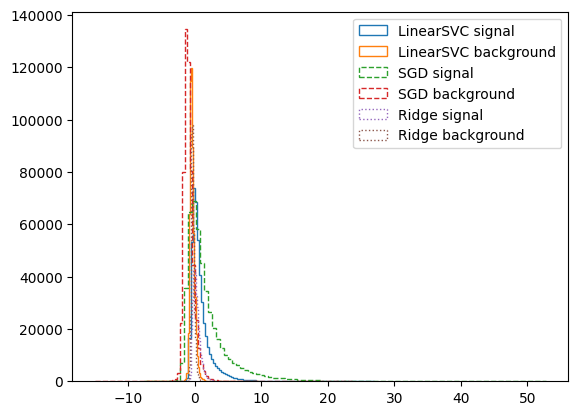

In [87]:
plt.figure()

plt.hist(svc_sig, bins=100, histtype="step", label="LinearSVC signal")
plt.hist(svc_bkg, bins=100, histtype="step", label="LinearSVC background")

plt.hist(sgd_sig, bins=100, histtype="step", linestyle="--", label="SGD signal")
plt.hist(sgd_bkg, bins=100, histtype="step", linestyle="--", label="SGD background")

plt.hist(ridge_sig, bins=100, histtype="step", linestyle=":", label="Ridge signal")
plt.hist(ridge_bkg, bins=100, histtype="step", linestyle=":", label="Ridge background")

plt.legend()
plt.show()

In [ ]:
#part c
`
#The best method is Stochastic Gradient Descent --> the curves for signal and background seem to be more separated compared to other methods

In [103]:
# scores on validation sample
scores = sgd_clf.decision_function(X_Test) #scoring the stochastic gradient descent classifier


# masks from true labels --> makes model evaluation unbiased to noticing patterns through already determined labels
sig_mask = (y_Test == 1)
bkg_mask = (y_Test == 0)

sig_scores = scores[sig_mask]
bkg_scores = scores[bkg_mask]

# scan thresholds
thresholds = np.linspace(scores.min(), scores.max(), 500)

best_thr = None
best_Z = -1
best_S = None
best_B = None

for thr in thresholds:
    S = np.sum(sig_scores > thr)
    B = np.sum(bkg_scores > thr)

    if S + B == 0:
        continue

    Z = S / np.sqrt(S + B) #this is the maximal significance function

    if Z > best_Z:
        best_Z = Z
        best_thr = thr
        best_S = S
        best_B = B

print("Best threshold:", best_thr) #best threshold for selecting mostly signal events -0.502665 and onwards
print("Best significance:", best_Z)
print("Signal yield:", best_S)
print("Background yield:", best_B)

Best threshold: -0.5026654918680293
Best significance: 517.7394088533899
Signal yield: 358703
Background yield: 121304


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

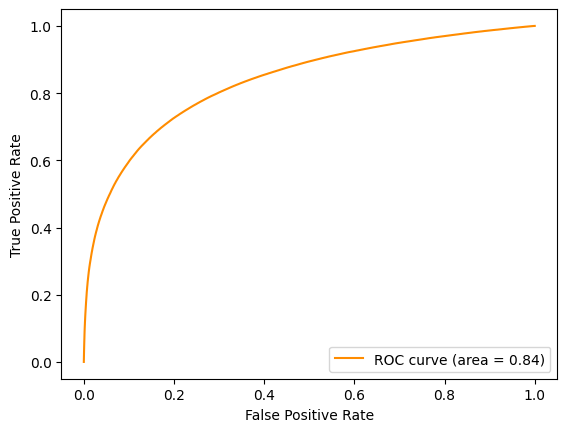

In [104]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [105]:
# Part a reading and notes

TPR --> true positive rate
FPR --> False positive rate
ROC --> Receiver operating characteristic
AUC --> Area under curve (classification metric representing the probability that a model ranks a random positive instance higher than a random negative one)

Precision and recall:
- performance metrics
- precision --> fraction of relevant instances among retreived instances (how close elements are to each other)
- recall (sensitivity) --> fraction of relevant instances that were retreived

Accuracy:
- accuracy --> how close a set of elements are to a true value

F-Score:
- F-Score --> measure of predictive performance, calculated from precision and recall
- F1 score --> harmonic mean of precision and recall

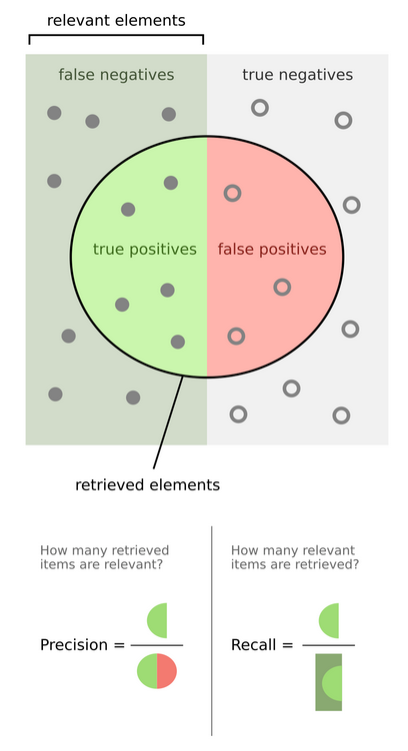

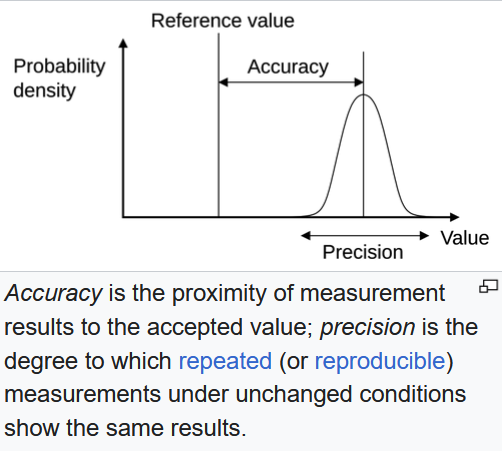

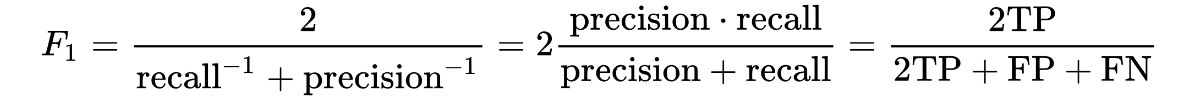

In [106]:
# Part b --> model evaluation compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy (using scikit-learn tools) of SGD model

In [109]:
from sklearn.metrics import recall_score #recall_score houses calculation for tpr score

y_pred = sgd_clf.predict(X_Test)
tpr = recall_score(y_Test, y_pred)

print(f"True Positive Rate: {tpr}")

True Positive Rate: 0.6555813308949814


In [111]:
from sklearn.metrics import confusion_matrix #confusion_matric houses calculation for fpr score

# Extract counts for binary classification
tn, fp, fn, tp = confusion_matrix(y_Test, y_pred).ravel()

# Compute FPR
fpr = fp / (fp + tn)
print(f"False Positive Rate: {fpr}")

False Positive Rate: 0.10122432706311016


In [ ]:
#roc_curve

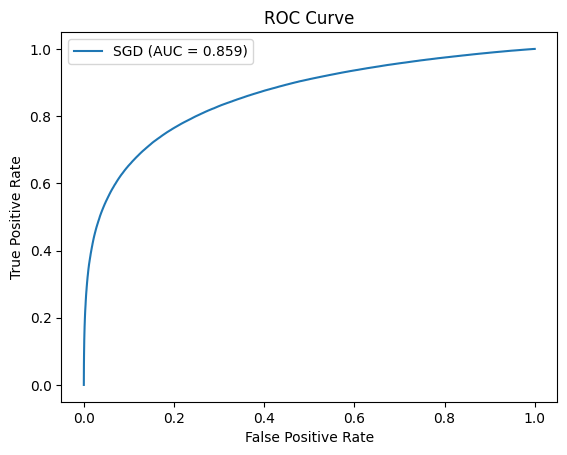

In [123]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get scores
sig_scores = sgd_clf.decision_function(Test_sig[VarNames[1:]])
bkg_scores = sgd_clf.decision_function(Test_bkg[VarNames[1:]])

# Build labels
y_true = np.concatenate([
    np.ones(len(sig_scores)),   # signal = 1
    np.zeros(len(bkg_scores))   # background = 0
])

# Combine scores
scores = np.concatenate([sig_scores, bkg_scores])

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, scores)

# AUC
auc = roc_auc_score(y_true, scores)

y=x
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"SGD (AUC = {auc:.3f})")
plt.plot(x,y)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#auc = 0.859 --> pretty good value slightly improved from previous ROC curve

In [126]:
precision = tp / (tp+fp) # calculating precision metric
recall = tp / (tp+fn) # calculating recall metric

print(precision)
print(recall)

0.8456294036014176
0.6555813308949814


In [129]:
from sklearn.metrics import f1_score, accuracy_score

In [132]:
print(f1_score(y_Test, y_pred)) #calculating f1 score
print(accuracy_score(y_Test, y_pred)) #calculating accuracy score

0.7385756537944294
0.787336
